# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [41]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [42]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [46]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [47]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [48]:
df.Segment.unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [49]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [50]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [51]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [52]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [53]:
query2 = """ SELECT
    c.customer_name,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.52
1,Sanjit Engle,134303.82
2,Clay Ludtke,130566.55
3,Adrian Barton,130262.14
4,Sanjit Chand,127281.01
5,Sean Miller,125215.25
6,Edward Hooks,123730.56
7,Greg Tran,118201.20
8,Seth Vernon,114709.50
9,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [54]:
query3 = """ select
    p.category as category,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY total_profit DESC;

"""
result3 = pd.read_sql(query3, conn)
result3

# I wrote the below code before watching the 
# video for clarification of the word 'or' in the prompt. 
# I reworked it to show just the most profitable category,
# but # didn't want to lose this code.

# =====================
# I used ChatGPT to help talk me through the logic.
# I created the CTEs but was struggling to 
# figure out how to show two one-row tables together

#Breaking down the logic:
    # - Find total profit for each category 
    # - Find total profit for each subcategory
    # - Order DESC and limit 1 to each


# WITH top_cat_profit as (
#     SELECT
#         p.category,
#         ROUND(SUM(od.profit), 2) AS total_profit
#     FROM products p
#     JOIN order_details od ON od.product_id = p.product_id
#     GROUP BY p.category
#     ORDER BY total_profit DESC LIMIT 1
# ),
# top_sub_cat_profit as (
#     SELECT
#         p.subcategory,
#         ROUND(SUM(od.profit), 2) AS total_profit
#     FROM products p
#     JOIN order_details od ON od.product_id = p.product_id
#     GROUP BY p.subcategory
#     ORDER BY total_profit DESC LIMIT 1
# )
# SELECT 
#     (SELECT category FROM top_cat_profit) as top_category,
#     (SELECT subcategory FROM top_sub_cat_profit ) as top_subcategory;

,category,total_profit
0,Technology,153415.70
1,Office Supplies,126113.35
2,Furniture,20098.89


In [55]:
query3_1 = """ select
    p.subcategory as subcategory,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM products p
JOIN order_details od ON od.product_id = p.product_id
WHERE p.category = 'Technology'
GROUP BY p.subcategory
ORDER BY total_profit DESC;

"""
result3_1 = pd.read_sql(query3_1, conn)
result3_1

,subcategory,total_profit
0,Copiers,55617.82
1,Accessories,48359.05
2,Phones,46936.19
3,Machines,2502.64


### What is the average discount given per category?

In [56]:
query4 = """ SELECT
    category,
    avg(discount)
FROM products p
JOIN order_details od ON od.product_id = p.product_id
GROUP BY category;

"""
result4 = pd.read_sql(query4, conn)
result4

,category,avg(discount)
0,Furniture,0.172514
1,Office Supplies,0.157000
2,Technology,0.132970


### Which states or regions contribute the most to total sales?

In [57]:
query5 = """ select
    c.state as top_selling_state,
    sum(od.sales) as total_sales
from customers c
join orders o on o.customer_id = c.customer_id
join order_details od on od.order_id = o.order_id
group by c.state
order by sum(od.sales) desc limit 1;
"""
result5 = pd.read_sql(query5, conn)
result5

# I wrote the below code before watching the 
# video for clarification. I reworked it to show
# just the highest-selling state above, but 
# didn't want to lose this code.

# with top_sales_states as (
#     SELECT
#         c.state,
#         sum(od.sales)
#     from customers c
#     join orders o on o.customer_id = c.customer_id
#     join order_details od on od.order_id = o.order_id
#     group by c.state
#     order by sum(od.sales) desc limit 1
# ), top_sales_regions as (
#     SELECT
#         c.region,
#         sum(od.sales)
#     from customers c
#     join orders o on o.customer_id = c.customer_id
#     join order_details od on od.order_id = o.order_id
#     group by c.region
#     order by sum(od.sales) desc limit 1
# )
# select 
#     (select state from top_sales_states) as top_state,
#     (select region from top_sales_regions) as top_region;


,top_selling_state,total_sales
0,California,3.314838e+06


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [58]:
query6 = """ 
with shipment_window as (select
    order_id,
    order_date,
    ship_date,
    (julianday(ship_date) - julianday(order_date)) as ship_delay
from orders)
select 
    count(ship_delay) as late_shipments
from shipment_window
where ship_delay >3;
"""
result6 = pd.read_sql(query6, conn)
result6

# As in most assignments, I checked my answer in ChatGPT
# This works, so I'm leaving it, but a cleaner solution was offered:
# select (*) as late_shipments
# from orders
# where (julianday(ship_date) - julianday(order_date)) > 3;

,late_shipments
0,3391


In [59]:
query6_1 = """ 
with shipment_window as (select
    order_id,
    order_date,
    ship_date,
    (julianday(ship_date) - julianday(order_date)) as ship_delay
from orders)
select 
    (select count(ship_delay) 
        from shipment_window
        where ship_delay <3) as on_time_shipments,
    (select count(ship_delay) 
        from shipment_window
        where ship_delay >3) as late_shipments;
"""
result6_1 = pd.read_sql(query6_1, conn)
result6_1

,on_time_shipments,late_shipments
0,1107,3391


### Which month or year had the highest total sales?

In [60]:
query7 = """ select
    strftime('%m', o.order_date) as year,
    round(sum(od.sales), 2) as total_sales
from orders o
join order_details od on od.order_id = o.order_id
group by year
order by total_sales desc limit 1;
"""
result7 = pd.read_sql(query7, conn)
result7

# select
#     strftime('%m', o.order_date) as month,
#     round(sum(od.sales), 2) as total_sales
# from orders o
# join order_details od on od.order_id = o.order_id
# group by month
# order by total_sales desc;

,year,total_sales
0,11,349120.07


### What are the most frequently ordered products?

In [61]:
query8 = """ select
    od.product_id,
    p.product_name,
    sum(od.quantity) as frequency
from order_details od
join products p on p.product_id = od.product_id
group by od.product_id
order by frequency desc limit 5;
"""
result8 = pd.read_sql(query8, conn)
result8

,product_id,product_name,frequency
0,TEC-AC-10003832,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,150
1,OFF-PA-10001970,Xerox 1881,140
2,OFF-BI-10002026,Avery Arch Ring Binders,128
3,TEC-AC-10002049,Logitech G19 Programmable Gaming Keyboard,120
4,FUR-FU-10001473,DAX Wood Document Frame,114


### Which customers placed more than 5 orders total?

In [62]:
query9 = """ 
with customer_orders as (
    select
        o.customer_id,
        c.customer_name,
        count(o.order_id) as total_orders
    from orders o
    join customers c on c.customer_id = o.customer_id
    group by o.customer_id
    order by total_orders desc
)
select *
from customer_orders
where total_orders > 5;
"""
result9 = pd.read_sql(query9, conn)
result9

# When checking my answer in ChatGPT, it 
# suggested I could avoid the CTE by using
# `HAVING` which helps me better understand
# how to use that clause.

,customer_id,customer_name,total_orders
0,EP-13915,Emily Phan,289
1,ZC-21910,Zuschuss Carroll,169
2,SH-19975,Sally Hughsby,169
3,JE-15745,Joel Eaton,169
4,EA-14035,Erin Ashbrook,169
...,...,...,...
742,BF-11080,Bart Folk,9
743,BD-11635,Brian Derr,9
744,AJ-10960,Astrea Jones,9
745,AC-10420,Alyssa Crouse,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [63]:
query10 = """ select
    p.category,
    round(sum(od.profit / od.sales), 2) as profit_margin
from order_details od
join products p on p.product_id = od.product_id
group by p.category
order by profit_margin desc;

"""
result10 = pd.read_sql(query10, conn)
result10

,category,profit_margin
0,Office Supplies,867.08
1,Technology,298.59
2,Furniture,94.71


####     Just for fun... Profit margin by customer category

In [64]:
query10 = """ select
    c.customer_category,
    round(sum(od.profit / od.sales), 2) as profit_margin
from order_details od
join orders o on o.order_id = od.order_id
join customers c on c.customer_id = o.customer_id
group by c.customer_category
order by profit_margin desc;

"""
result10 = pd.read_sql(query10, conn)
result10

,customer_category,profit_margin
0,Consumer,4092.73
1,Corporate,2708.96
2,Home Office,1723.41


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

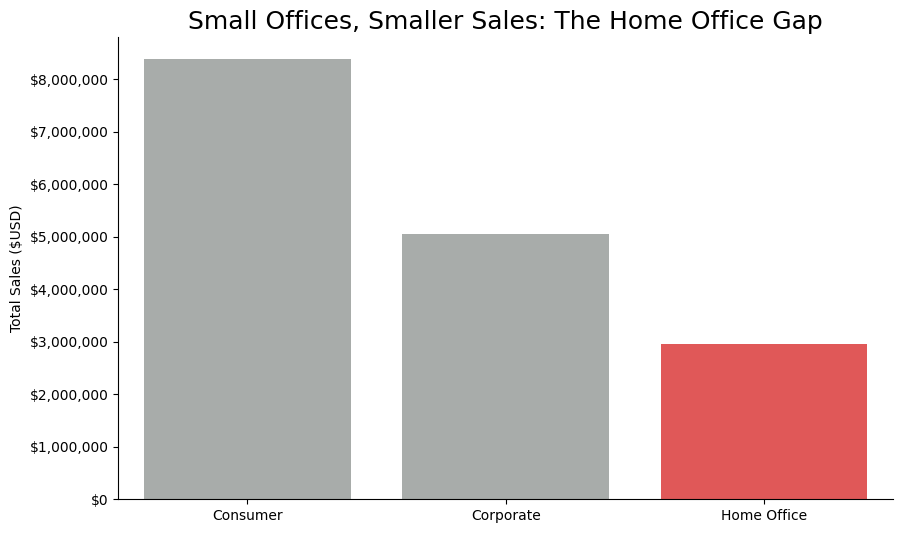

In [65]:
# example using result1
plt.figure(figsize=(10,6))

colors = ["#a7adaa", "#a7adaa", "#f74141" ]

sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)

plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


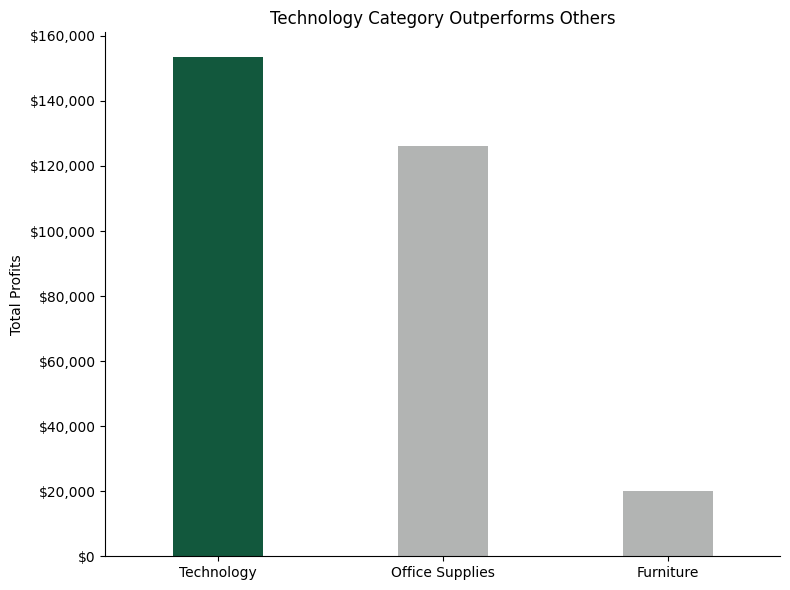

In [66]:
# Which product category is the most profitable overall?

plt.figure(figsize=(8,6))

# top_profit = 'Technology'
profit_colors = ["#066440", "#B2B4B3", "#B2B4B3"]
# profit_colors = ["#d8c834" if category == top_profit else     "#a93aca" for category in x]

sns.barplot(result3, x='category', y='total_profit', palette=profit_colors, hue='category', width=.4)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Technology Category Outperforms Others')
plt.ylabel('Total Profits')
plt.xlabel('')

ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()

plt.show()

# References:
#   - Formatting money ticks
#       - https://matplotlib.org/stable/gallery/ticks/dollar_ticks.html
#       - https://stackoverflow.com/questions/38152356/dollar-sign-with-thousands-comma-tick-labels 

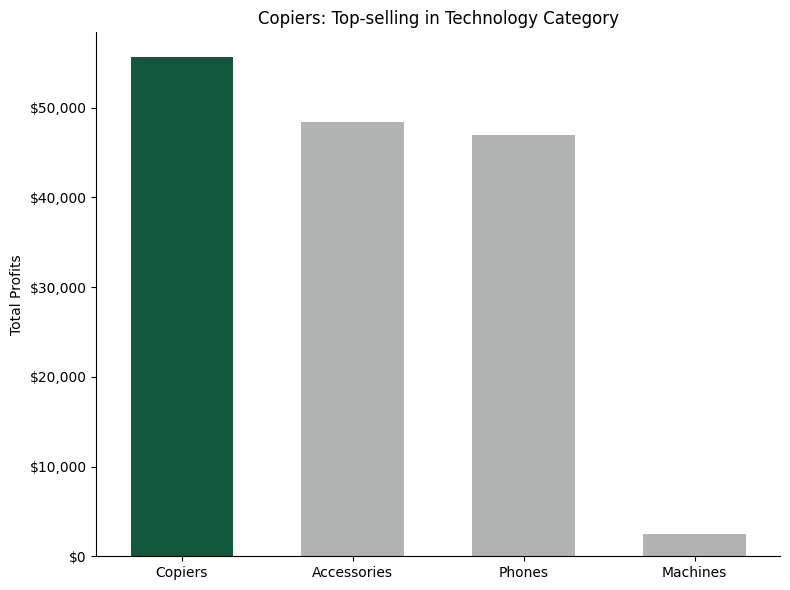

In [67]:
# BONUS CHART (to satisfy my curiosity)

# Which TECHNOLOGY subcategory is the most profitable overall?

plt.figure(figsize=(8,6))

# top_profit = 'Technology'
profit_colors = ["#066440", "#B2B4B3", "#B2B4B3", "#B2B4B3"]
# profit_colors = ["#d8c834" if category == top_profit else     "#a93aca" for category in x]

sns.barplot(result3_1, x='subcategory', y='total_profit', palette=profit_colors, hue='subcategory', width=.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Copiers: Top-selling in Technology Category')
plt.ylabel('Total Profits')
plt.xlabel('')

ax.yaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()

plt.show()

In [68]:
# How many orders were shipped late?

# Turn df into series for pie chart

result6_1_series = result6_1.squeeze()
result6_1_series

on_time_shipments    1107
late_shipments       3391
Name: 0, dtype: int64

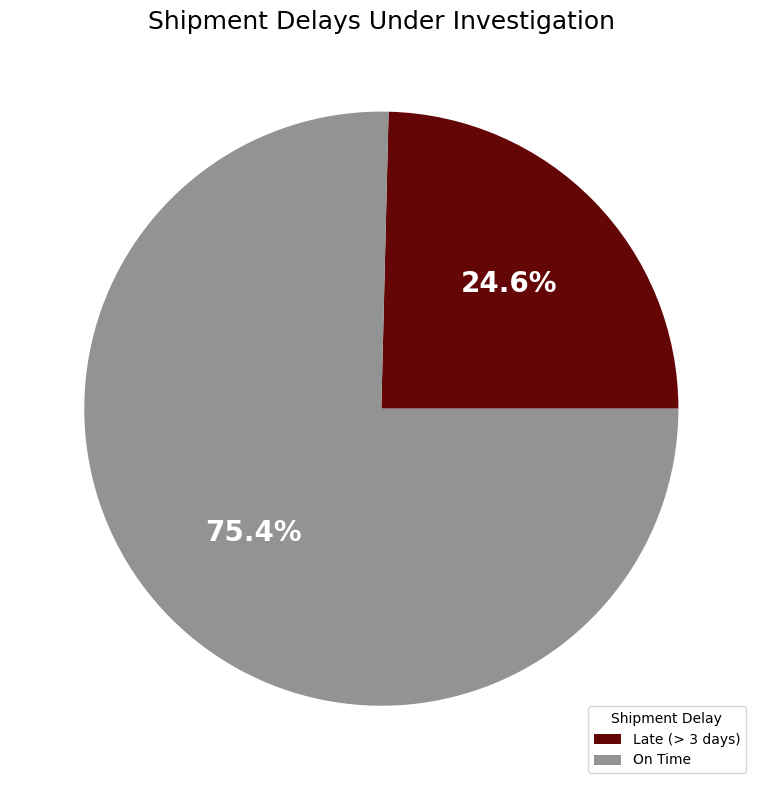

In [75]:
plt.figure(figsize=(8,8))

plt.pie(
    result6_1_series,
    labels=None,
    colors = ["#640606", "#929493"],
    autopct='%1.1f%%',
    textprops={'fontsize': 20, 'color': 'white', 'weight' : 'bold'})

plt.title("Shipment Delays Under Investigation",
        fontsize = 18)
plt.legend(
    labels={'Late (> 3 days)', 'On Time'},
    loc='lower right',
    title='Shipment Delay'
)

plt.tight_layout()
plt.show()

<Figure size 1600x800 with 0 Axes>

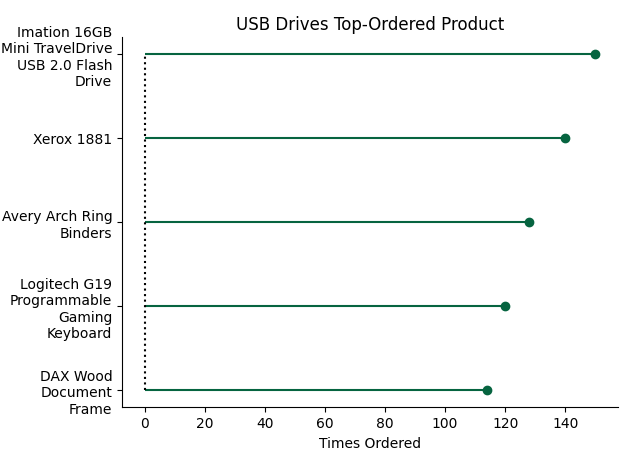

In [ ]:
# What are the most frequently ordered products (query8); lollipop

# TO INSTRUCTOR: I wanted to try out a new chart; I realize that
# a bar chart would likely be better here...

# Reverse data
# COMMENTED OUT TO PREVENT FLIPPING OF CHART WHILE WORKING
# result8 = result8.loc[::-1]

plt.figure(figsize=(16,8))
fig, ax = plt.subplots()

ax.stem(
        result8['product_name'], 
        result8['frequency'],
        orientation='horizontal',
        linefmt="#066440",
        basefmt='k:'
        )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Times Ordered')
plt.title('USB Drives Top-Ordered Product')
plt.yticks(result8['product_name'], wrap=True)

plt.show()

# References:
#   https://python-graph-gallery.com/lollipop-plot/
#   https://www.geeksforgeeks.org/python/create-lollipop-charts-with-pandas-and-matplotlib/
#   https://www.youtube.com/watch?v=rAJ4hoor6W0

In [71]:
# - What's the profit margin by category or customer category (query10) **stacked line chart with sales/profit**

### Feedback or Questions
- 